# Prophet 时序预测——能源价格（含协变量）

使用 Facebook Prophet 预测德国未来 24 小时电价，以 **Ampirion 负荷预测** 和 **光伏+风电出力预测** 为已知未来协变量，并与不含协变量的基线对比。

数据：AutoGluon electricity_price（训练集 51936 行，2012-01-09 ~ 2017-12-11，小时级）

预测目标：2017-12-12 00:00 ~ 23:00（24 小时）

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from prophet import Prophet

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

TIMESERIES_ID   = 'DE'
PREDICTION_LENGTH = 24
SHOW_HISTORY    = 256  # 可视化时显示最近 256 个历史点

energy_context_df = pd.read_parquet(
    'https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet',
    engine='fastparquet'
)
energy_context_df['timestamp'] = pd.to_datetime(energy_context_df['timestamp'])

energy_test_df = pd.read_parquet(
    'https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet',
    engine='fastparquet'
)
energy_test_df['timestamp'] = pd.to_datetime(energy_test_df['timestamp'])

print('训练数据:', energy_context_df.shape, '| 列:', list(energy_context_df.columns))
print(f'时间范围: {energy_context_df["timestamp"].min().date()} ~ {energy_context_df["timestamp"].max().date()}')
print('预测目标日:', energy_test_df['timestamp'].min().date())
energy_context_df.head(3)

训练数据: (51936, 5) | 列: ['id', 'timestamp', 'target', 'Ampirion Load Forecast', 'PV+Wind Forecast']
时间范围: 2012-01-09 ~ 2017-12-11
预测目标日: 2017-12-12


,id,timestamp,target,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2012-01-09 00:00:00,34.970001,16382.0,3569.527588
1,DE,2012-01-09 01:00:00,33.430000,15410.5,3315.274902
2,DE,2012-01-09 02:00:00,32.740002,15595.0,3107.307617


In [7]:
# 协变量列重命名（Prophet 不允许含空格/特殊字符的列名）
COV_MAP = {
    'Ampirion Load Forecast': 'ampirion_load',
    'PV+Wind Forecast':       'pv_wind',
}
COV_COLS = list(COV_MAP.values())

df_context = (
    energy_context_df[energy_context_df['id'] == TIMESERIES_ID]
    .rename(columns={'timestamp': 'ds', 'target': 'y', **COV_MAP})
    [['ds', 'y'] + COV_COLS]
    .reset_index(drop=True)
)

df_future_cov = (
    energy_test_df[energy_test_df['id'] == TIMESERIES_ID]
    .rename(columns={'timestamp': 'ds', **COV_MAP})
    [['ds'] + COV_COLS]
    .reset_index(drop=True)
)

print(f'历史上下文: {len(df_context)} 行  ({df_context["ds"].min().date()} ~ {df_context["ds"].max().date()})')
print(f'未来协变量: {len(df_future_cov)} 行  ({df_future_cov["ds"].iloc[0]} ~ {df_future_cov["ds"].iloc[-1]})')
df_context.tail(3)

历史上下文: 51936 行  (2012-01-09 ~ 2017-12-11)
未来协变量: 24 行  (2017-12-12 00:00:00 ~ 2017-12-12 23:00:00)


,ds,y,ampirion_load,pv_wind
51933,2017-12-11 21:00:00,34.430000,24825.0,18815.535156
51934,2017-12-11 22:00:00,31.950001,23649.0,18973.365234
51935,2017-12-11 23:00:00,27.350000,21941.0,19076.228516


In [8]:
# 训练 Prophet 模型（含协变量）
m_with_cov = Prophet(
    yearly_seasonality=10,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode='additive',
    interval_width=0.8,
)
for col in COV_COLS:
    m_with_cov.add_regressor(col)

m_with_cov.fit(df_context)
print('Prophet 模型训练完成（含协变量）')

10:37:24 - cmdstanpy - INFO - Chain [1] start processing
10:38:10 - cmdstanpy - INFO - Chain [1] done processing


Prophet 模型训练完成（含协变量）


In [9]:
# 预测：拼接历史时间戳（含协变量）+ 未来 24 小时协变量
df_pred_input   = pd.concat([df_context[['ds'] + COV_COLS], df_future_cov], ignore_index=True)
forecast_w_cov  = m_with_cov.predict(df_pred_input)
future_w_cov    = forecast_w_cov.tail(PREDICTION_LENGTH)

print('预测完成')
future_w_cov[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

预测完成


,ds,yhat,yhat_lower,yhat_upper
51936,2017-12-12 00:00:00,26.804433,16.981578,36.224084
51937,2017-12-12 01:00:00,24.209532,14.422953,34.470523
51938,2017-12-12 02:00:00,21.515086,11.643089,31.117840
51939,2017-12-12 03:00:00,19.374458,9.426121,29.074879
51940,2017-12-12 04:00:00,18.550629,8.352010,28.166285
51941,2017-12-12 05:00:00,21.072721,11.769570,30.767517
51942,2017-12-12 06:00:00,29.688871,19.306263,39.833751
51943,2017-12-12 07:00:00,38.057074,28.367615,48.438662
51944,2017-12-12 08:00:00,42.705985,32.645711,52.267064
51945,2017-12-12 09:00:00,43.086993,32.995944,52.161773


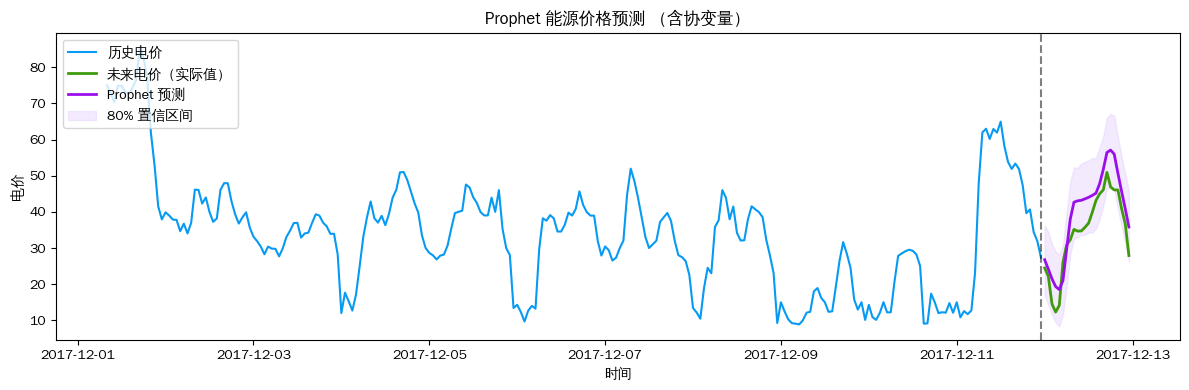

In [10]:
def plot_prophet_energy(df_context, future_forecast, energy_test_df,
                        timeseries_id, title_suffix=''):
    df_hist = df_context.tail(SHOW_HISTORY)
    df_gt   = (energy_test_df[energy_test_df['id'] == timeseries_id]
               .rename(columns={'timestamp': 'ds'}))

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df_hist['ds'], df_hist['y'],
            label='历史电价', color='xkcd:azure')
    ax.plot(df_gt['ds'], df_gt['target'],
            label='未来电价（实际值）', color='xkcd:grass green', linewidth=2)
    ax.plot(future_forecast['ds'], future_forecast['yhat'],
            label='Prophet 预测', color='xkcd:violet', linewidth=2)
    ax.fill_between(future_forecast['ds'],
                    future_forecast['yhat_lower'], future_forecast['yhat_upper'],
                    alpha=0.35, label='80% 置信区间', color='xkcd:light lavender')
    ax.axvline(x=df_context['ds'].max(), color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'Prophet 能源价格预测 {title_suffix}')
    ax.set_xlabel('时间')
    ax.set_ylabel('电价')
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

plot_prophet_energy(df_context, future_w_cov, energy_test_df,
                    TIMESERIES_ID, title_suffix='（含协变量）')

10:38:55 - cmdstanpy - INFO - Chain [1] start processing
10:39:15 - cmdstanpy - INFO - Chain [1] done processing


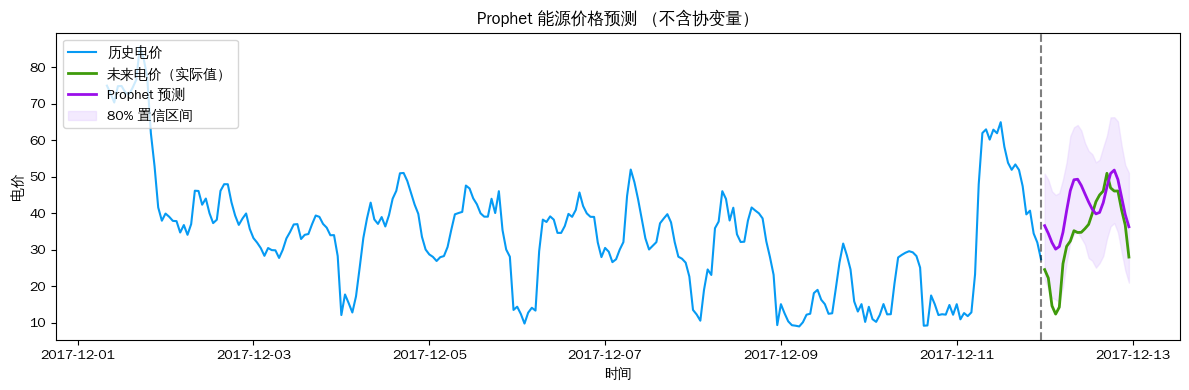

In [11]:
# 对比：不含协变量的基线
m_no_cov = Prophet(
    yearly_seasonality=10,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode='additive',
    interval_width=0.8,
)
m_no_cov.fit(df_context[['ds', 'y']])

future_no_cov_input  = m_no_cov.make_future_dataframe(periods=PREDICTION_LENGTH, freq='h')
forecast_no_cov      = m_no_cov.predict(future_no_cov_input)
future_no_cov        = forecast_no_cov.tail(PREDICTION_LENGTH)

plot_prophet_energy(df_context, future_no_cov, energy_test_df,
                    TIMESERIES_ID, title_suffix='（不含协变量）')

In [12]:
# 误差指标对比
gt = (energy_test_df[energy_test_df['id'] == TIMESERIES_ID]
      .sort_values('timestamp')['target'].values)

def calc_metrics(y_true, y_pred, label):
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{label}  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%')

print('─' * 55)
calc_metrics(gt, future_w_cov['yhat'].values,   'Prophet 含协变量:  ')
calc_metrics(gt, future_no_cov['yhat'].values,  'Prophet 不含协变量:')
print('─' * 55)

───────────────────────────────────────────────────────
Prophet 含协变量:    MAE=5.671  RMSE=6.184  MAPE=19.00%
Prophet 不含协变量:  MAE=8.724  RMSE=10.135  MAPE=36.02%
───────────────────────────────────────────────────────
